In [ ]:
# Clean slate — safe to re-run; no-op on cold kernel
get_ipython().run_line_magic('reset','-sf'); import gc, matplotlib.pyplot as plt; plt.close('all'); gc.collect()

# Notebook 13 — Experimental Effects on Flight Kinematics

> **Supplementary §14**

This notebook uses heatmaps to visualise how experimental conditions and individual differences affect morphing flight. Each shape change mode score is represented as a row with conditions stacked for comparison.

The heatmaps are scaled to the 1st and 99th percentiles of each mode's score distribution: blue indicates negative scores, red indicates positive scores, and yellow indicates values near the mean hawk shape.

> **NOTE**: To understand what positive and negative scores mean for shape changes, use Notebook 09 to visualise each with different scores. 

These heatmaps provide a closer look at individual flight behaviour for consistent behaviours. As within- and across-individual variation is high, they do not represent stereotyped generalisable behaviours. Different analytical approaches would be required for quantitative comparison across individuals with variable wingbeat frequencies.


## Contents
1. [Setup and data loading](#setup)
2. [Heatmap comparisons — obstacle flights](#obstacle-heatmaps)
3. [Heatmap comparisons — weight effect](#weight-heatmaps)
4. [Heatmap comparisons — naive vs experienced](#naive-heatmaps)
5. [Summary](#summary)

In [2]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from morphing_birds import Animal3D, animate_plotly, animate_mode

from kinematic_morphospace import (
    filter_by, run_PCA, apply_sign_conventions,
    get_score_df, get_score_range, prepare_heatmap_mode_order,
    reconstruct, to_bilateral,
)
from kinematic_morphospace.plotting import (
    save_figure,
    prepare_heatmap_comparison, plot_difference_PC_scores_heatmap,
    plot_difference_exp_scores_heatmap,
)

CONFIG = {
    "bin_size": 0.07,
    "fig_dir": Path("../../figures/supplementary"),
}

## Load Data and Prepare Scores

In [3]:
unilateral_data = np.load("../../data/unilateral/data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/unilateral/frame_info.csv")

filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

scores_df, horz_dist_bins = get_score_df(scores, unilateral_frame_info_df, size_bin=CONFIG["bin_size"])
PC_cols = prepare_heatmap_mode_order(scores_df)

print(f"Total frames: {scores.shape[0]:,}")
print(f"Scores dataframe: {scores_df.shape}")
print(f"Mode order: {PC_cols}")

  Sign conventions applied: PC07 negated (positive = m-folded)
Total frames: 289,528
Scores dataframe: (289528, 27)
Mode order: ['PC01', 'PC02', 'PC03', 'PC04', 'PC05', 'PC08', 'PC06', 'PC07', 'PC09']


### Checking sign conventions with animation

The sign conventions for each mode (e.g. PC07 negated so positive = m-folded) are applied automatically by `get_score_df` for heatmaps. The animation below uses raw scores for reconstruction (so the 3D shape is correct) and applies sign conventions only to the slider labels (so the displayed values match the heatmaps). Use this to verify what positive and negative scores look like for any mode.

In [4]:
colour_list = ['#B5E675', '#6ED8A9', '#51B3D4',
               '#4579AA', '#F19EBA', '#BC96C9',
               '#917AC2', '#BE607F', '#624E8B',
               '#888888', '#888888', '#888888']

mu = np.load("../../data/unilateral/mean_shape.npy").reshape(1, -1, 3)
hawk3d = Animal3D('hawk', '../../data/mean_hawk_shape.csv')

# Change the mode number to check any mode (1–9)
animate_mode(7, hawk3d, principal_components, scores, mu, colour_list,
             sign_fn=apply_sign_conventions)

  Sign conventions applied: PC07 negated (positive = m-folded)


## Heatmap Comparisons — Obstacle Flights

Comparing control and obstacle flights for individual hawks. The upper row of each heatmap shows the obstacle condition; the lower row shows the control. The vertical line indicates the obstacle position (−4.5 m from the landing perch). Flights with added weight (IMU) are excluded.

### Colour interpretation

The heatmaps are scaled to the 1st and 99th percentiles of each morphing mode's score distribution:
- **Blue** — negative scores (e.g., wings lowered, contracted, or swept back relative to the mean)
- **Red** — positive scores (e.g., wings raised, spread, or swept forward relative to the mean)
- **Yellow** — values near the mean hawk shape

Condition 1: Number of frames: 18092; Number of flights: 50
Condition 2: Number of frames: 7896; Number of flights: 33
--- Toothless ---


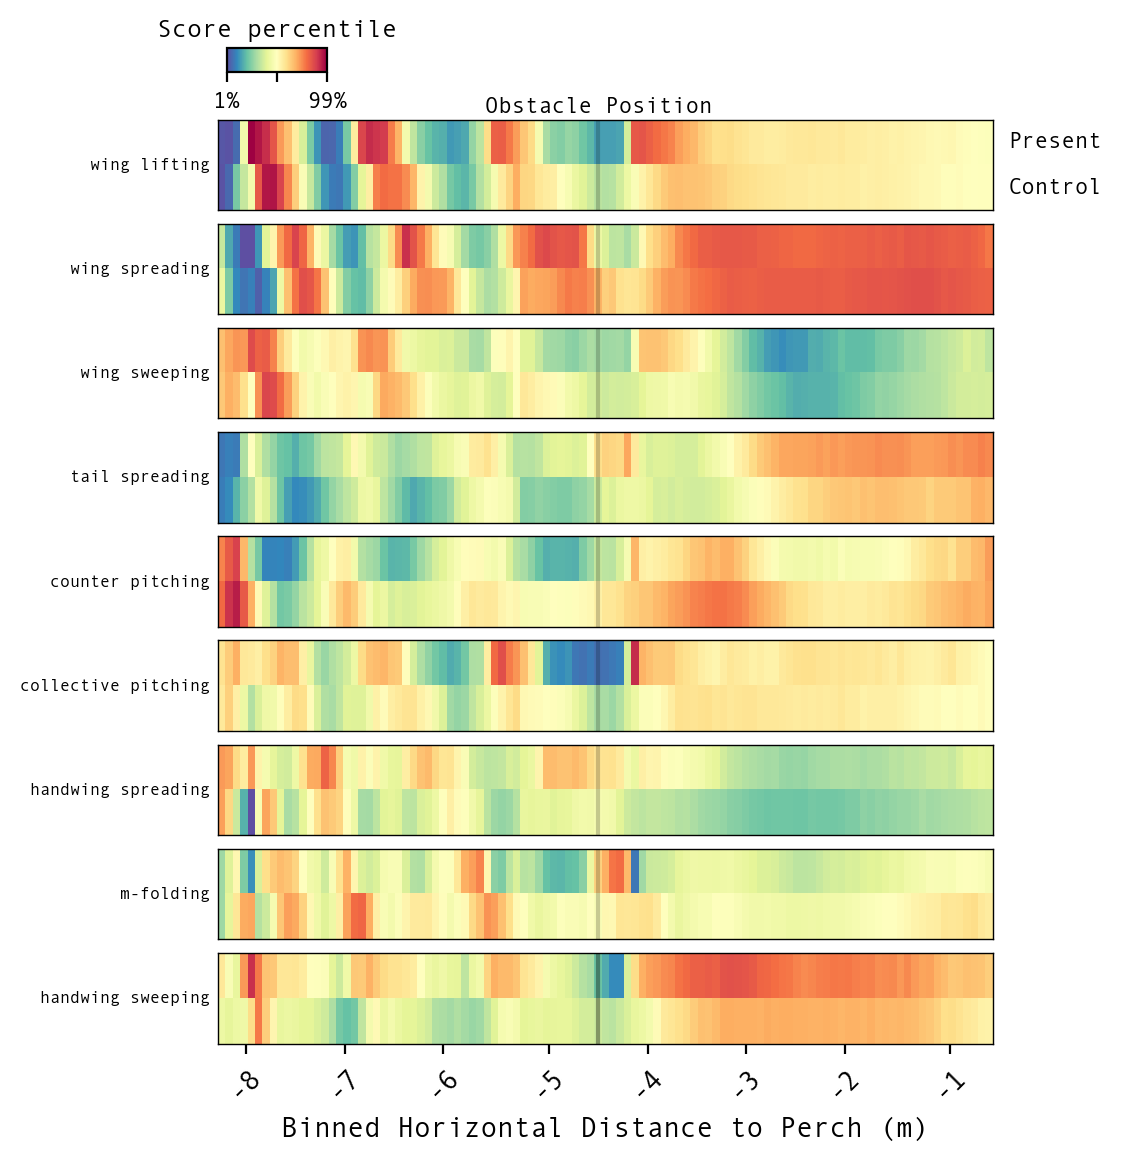

Saved: ../../figures/supplementary/S12_obstacle_Toothless.pdf
Condition 1: Number of frames: 11136; Number of flights: 48
Condition 2: Number of frames: 4998; Number of flights: 32
--- Ruby ---


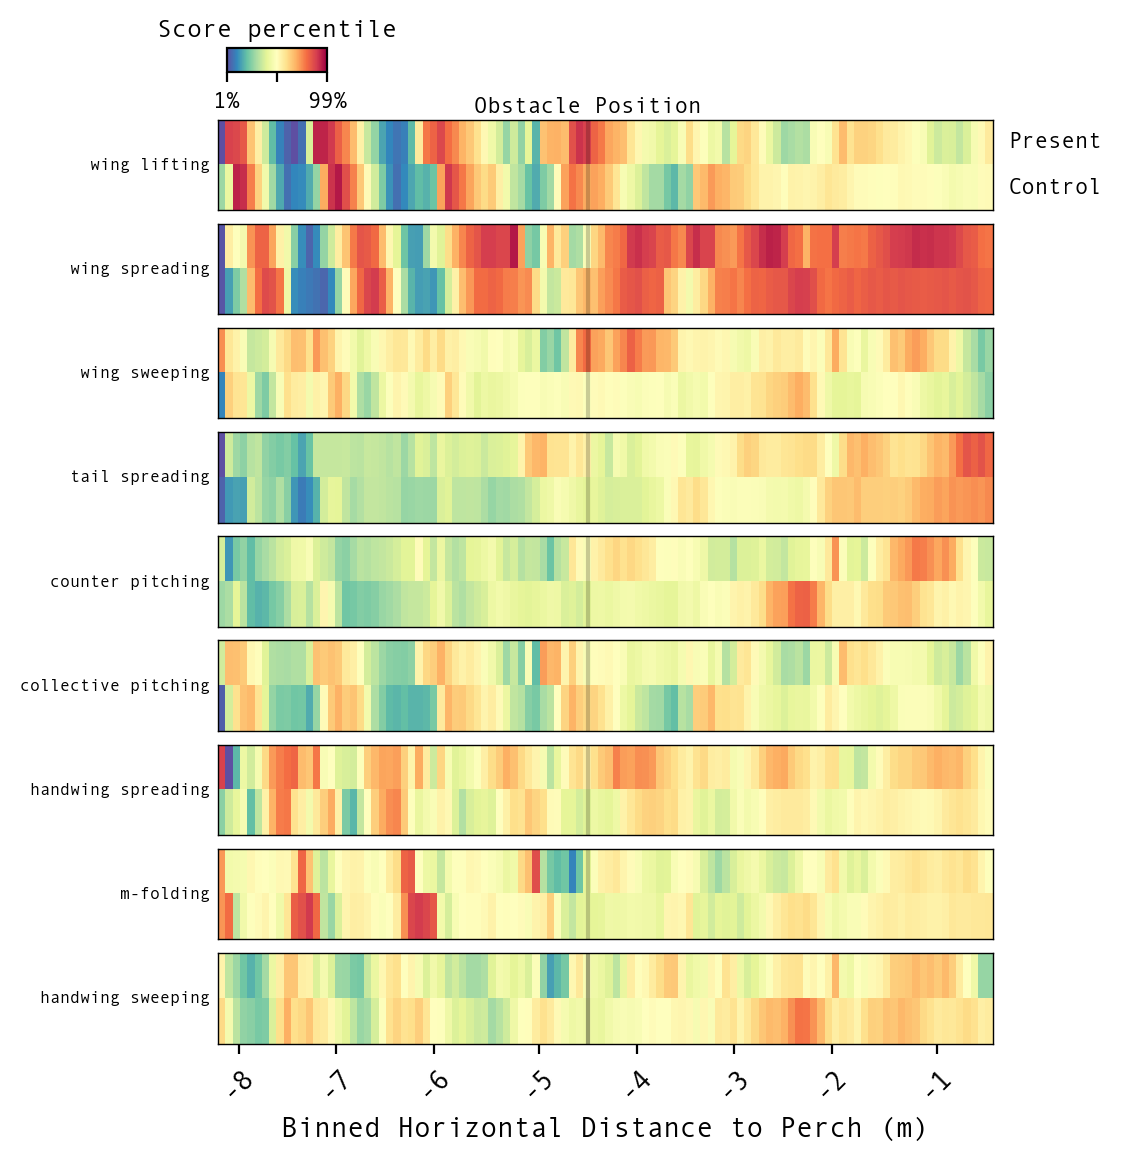

Saved: ../../figures/supplementary/S12_obstacle_Ruby.pdf


In [5]:
plt.close("all")
hawks = ["Toothless", "Ruby"]

for hawk in hawks:
    control_df, obstacle_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk, "year": 2020},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
        condition2={"obstacle": 1, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
    )
    print(f"--- {hawk} ---")
    ax = plot_difference_PC_scores_heatmap(control_df, obstacle_df, PC_cols, score_5, score_95)
    save_figure(ax, CONFIG["fig_dir"] / f"S12_obstacle_{hawk}.pdf")

The obstacle triggers both a localised span-reduction and a broader postural shift, visible in the lower-order morphing modes:

- **Wing spreading (PC02)** shows a negative dip at 6.5–4.5 m in both hawks (Toothless −0.017, Ruby −0.036) — wings fold immediately before the obstacle, then recover afterwards. This is a span-reduction manoeuvre for gap negotiation.
- **Wing sweep (PC03)** after the obstacle, there is a positive sweep to recover from the turn and reposition in line with the destination perch. 
- **Tail Spreading (PC04)** Ruby and Toothless both use an increase in tail span around the obstacle.
- **Pitching (PC05 & PC08)** This shows high individual variation. Toothless uses a strong collective pitching signature near the perch, likely banking the tail to induce the turn. In general the wings are pitched less during obstacle flights, even early on in the approach. Ruby on the other hand shows a strong wing positive pitch during the glide phase, which is delayed considerably after the obstacle and much closer to the perch. The individual differences in pitching strategy may reflect different approaches to the turn and different ways of using the tail and angle of attack for control. 
- **Handwing spreading (PC06)** increases in both hawks across the flight, suggesting the handwing spreads further to maintain control authority while manoeuvring.
- **M-folding (PC07)** shifts negative (toward w-folding) in both hawks close to the obstacle. Toothless shows m-folding after the obstacle while Ruby shows m-folding during the approach and then stays neutral during gliding. 
- **Handwing sweeping (PC09)** Toothless uses far more positive handwing sweep across the entire flight with one negative dip around the obstacle. Ruby shows more measured but variable handwing sweep throughout the flight. 

In summary the changes in morphing throughout the different flight behaviours as well as with and without an obstacle are complex and individual-specific. Some morphing differences are apparent around the obstacle, but other differences start early in the approach and are apparent in the gliding phase too. The obstacle flights are not simply "control flights + a span-reduction at the obstacle", but instead show a complex pattern of morphing differences across the entire approach, with some consistent features (span reduction, tail spreading) and some individual-specific features (pitching strategy, handwing sweep).

## Heatmap Comparisons — Weight Effect

Comparing flights with and without an added weight (IMU) for individual hawks. The upper row shows the weighted condition; the lower row shows the control.

Condition 1: Number of frames: 8906; Number of flights: 45
Condition 2: Number of frames: 2750; Number of flights: 16
--- Charmander: weight vs control ---


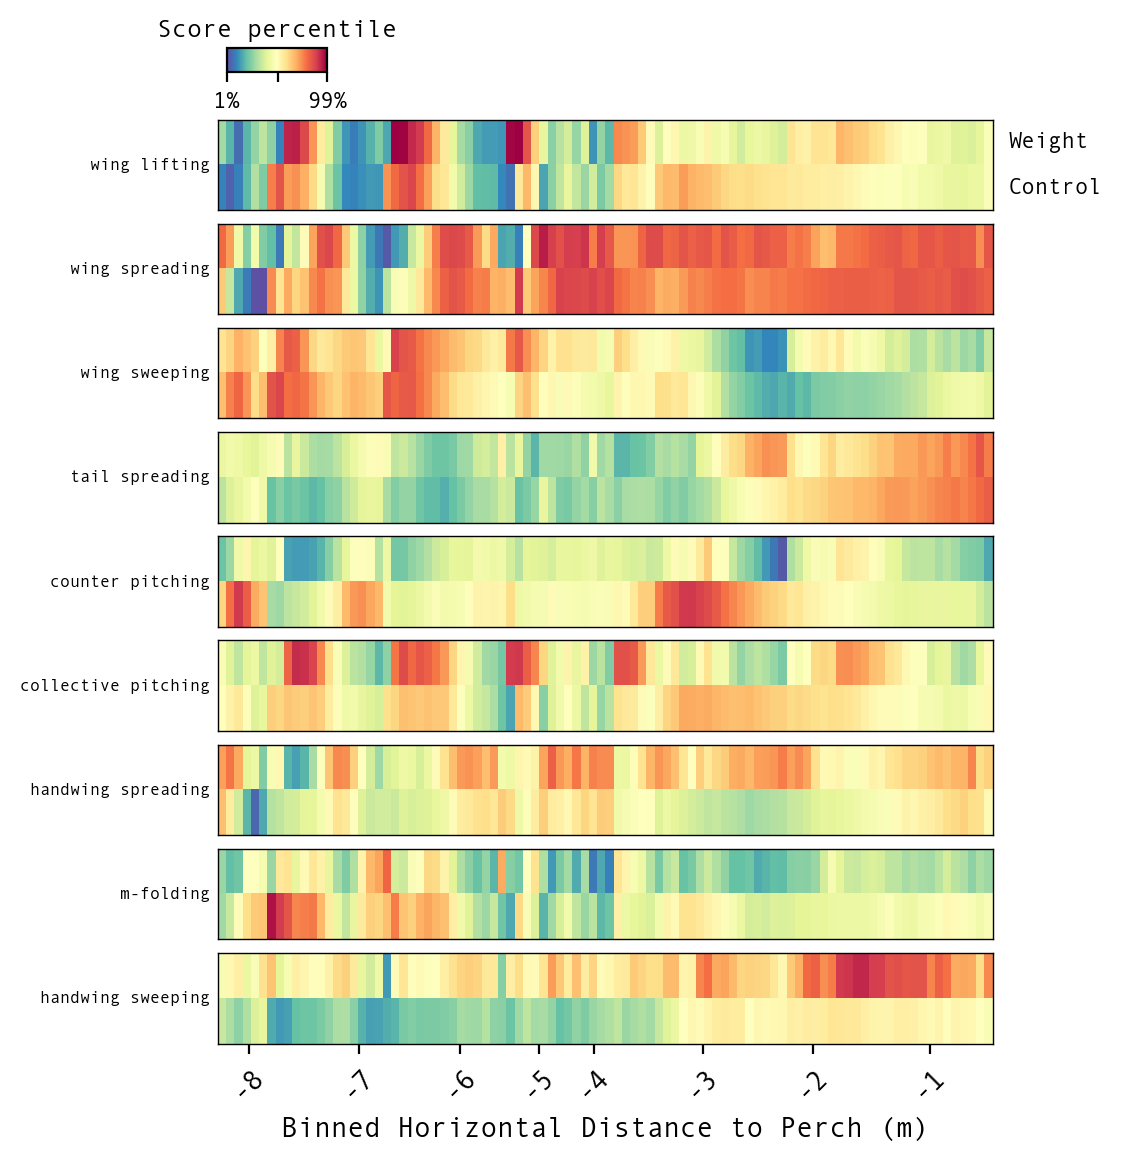

Saved: ../../figures/supplementary/S12_weight_Charmander.pdf
Condition 1: Number of frames: 11136; Number of flights: 48
Condition 2: Number of frames: 4394; Number of flights: 18
--- Ruby: weight vs control ---


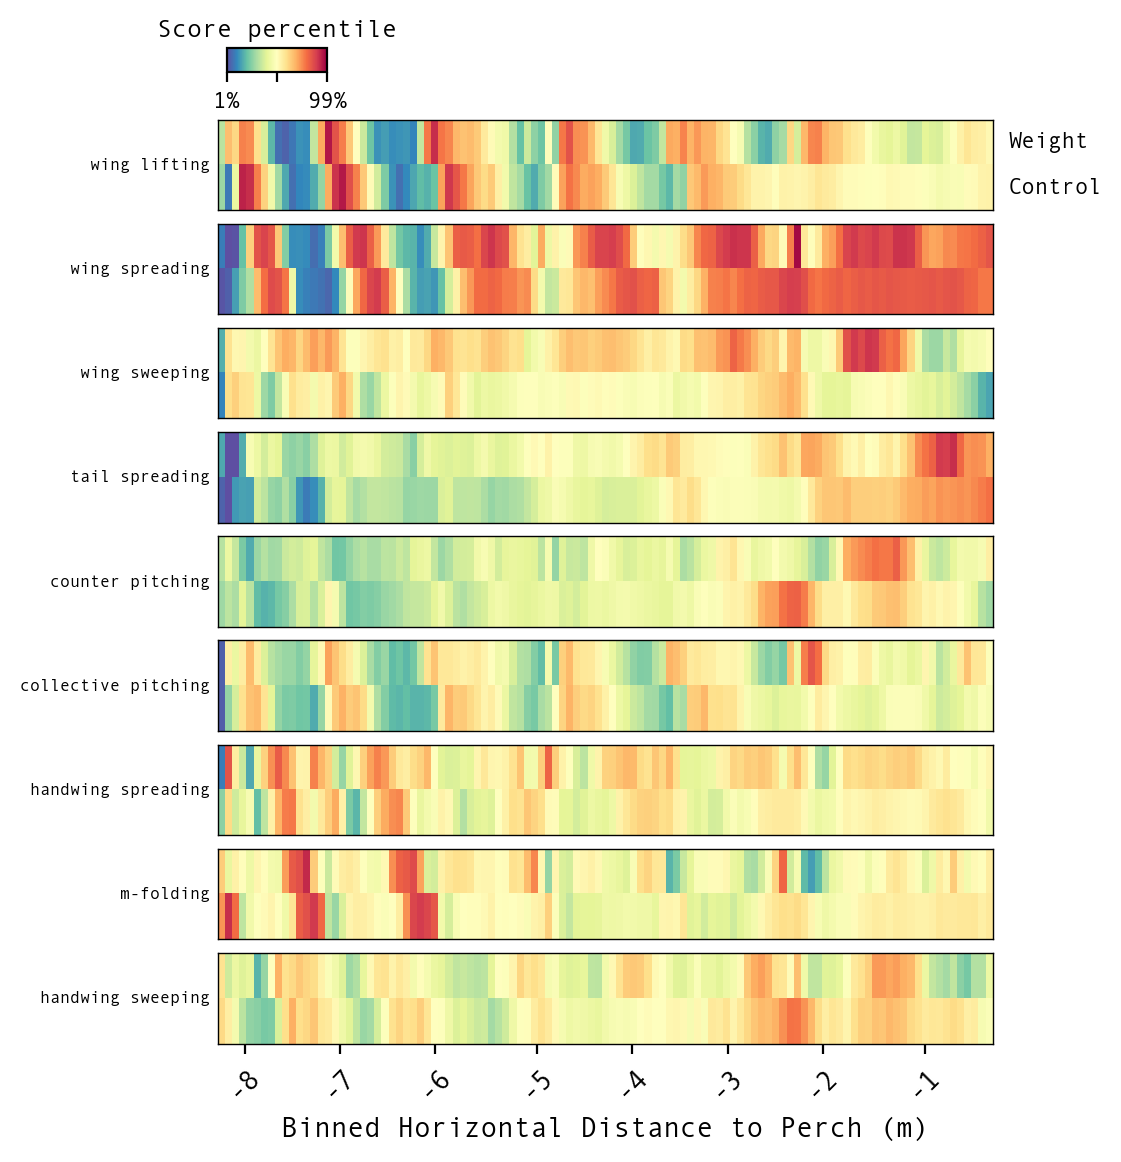

Saved: ../../figures/supplementary/S12_weight_Ruby.pdf


In [6]:
plt.close("all")
hawks = ["Charmander", "Ruby"]

for hawk in hawks:
    control_df, weight_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk, "year": 2020},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "IMU": 0, "hawkname": hawk},
        condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "IMU": 1, "hawkname": hawk},
    )
    print(f"--- {hawk}: weight vs control ---")
    ax = plot_difference_exp_scores_heatmap(
        control_df, "Control", weight_df, "Weight", PC_cols, score_5, score_95
    )
    save_figure(ax, CONFIG["fig_dir"] / f"S12_weight_{hawk}.pdf")

Again, individual variation is high. 

- **Wing Lifting (PC01)** Charmander raises his wings higher when under load, with the darker red bands during flapping. The wingbeat timing also shifts a little. In the glide he uses lower wing position, but raising them briefly before landing.
Ruby notably does not use a gliding phase when flying with a weight, the stripes of wings raising and lowering are present all the way to the perch. Her wingbeat frequency is also altered. 
- **Wing Spreading (PC02)** Again, wingbeat patterns are altered. 
- **Wing Sweeping (PC03)** Charmander uses more variable sweep with an added load, with a positve then negative signature during his approach to the perch. Ruby shows more positive sweep throughout the flight with added load, possibly to move the centre of pressure forward to compensate for the added dorsal mass.
- **Tail Spreading (PC04)** For Charmander, tail spreading happens earlier in the glide with added load. Ruby has a strong positive span increase close to the perch with added load. Unlike the control flights Ruby does not have a glide phase, and so this seems to be an altered braking strategy. 
- **Handwing modes (PC06 & PC09)** While Ruby has variation in her handwing shape changes, Charmander shows a strong increase with added load. He uses handwing compensation while Ruby shifts to flapping all the way to the perch. This may reflect Ruby's overall larger size as a female, while Charmander is juvenile and inexperienced and so shows more changes.

## Heatmap Comparisons — Naive vs Experienced

Two hawks (Drogon, Toothless) were recorded as both naive juveniles (Period 1) and experienced adults (Period 2). The comparison reveals how flight morphing patterns change with experience.

Condition 1: Number of frames: 14550; Number of flights: 76
Condition 2: Number of frames: 7312; Number of flights: 46
--- Drogon: naive vs experienced ---


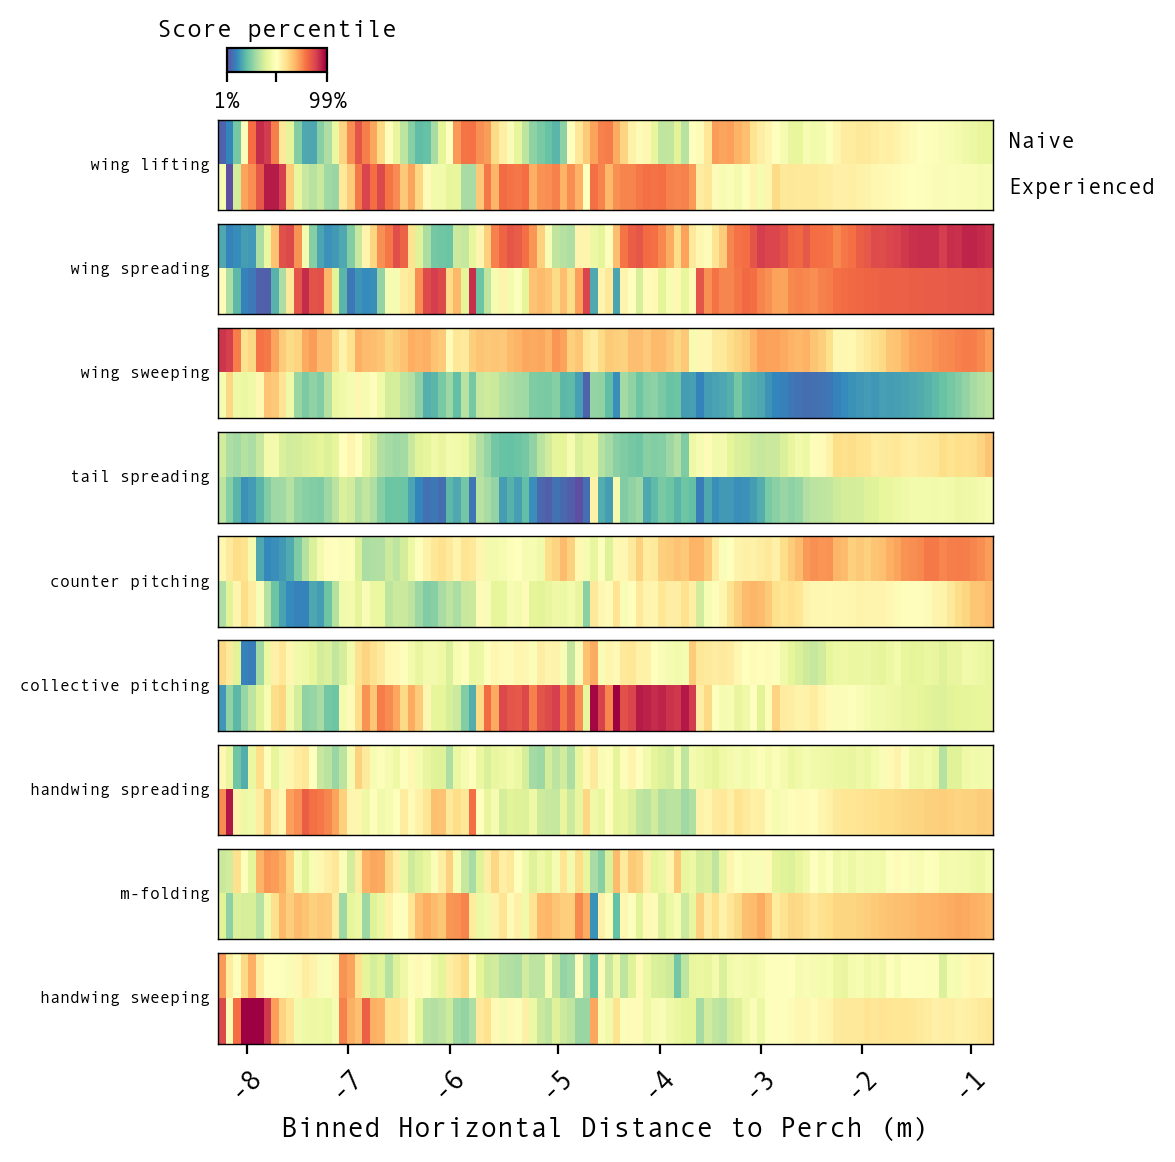

Saved: ../../figures/supplementary/S12_experience_Drogon.pdf
Condition 1: Number of frames: 14778; Number of flights: 58
Condition 2: Number of frames: 18092; Number of flights: 50
--- Toothless: naive vs experienced ---


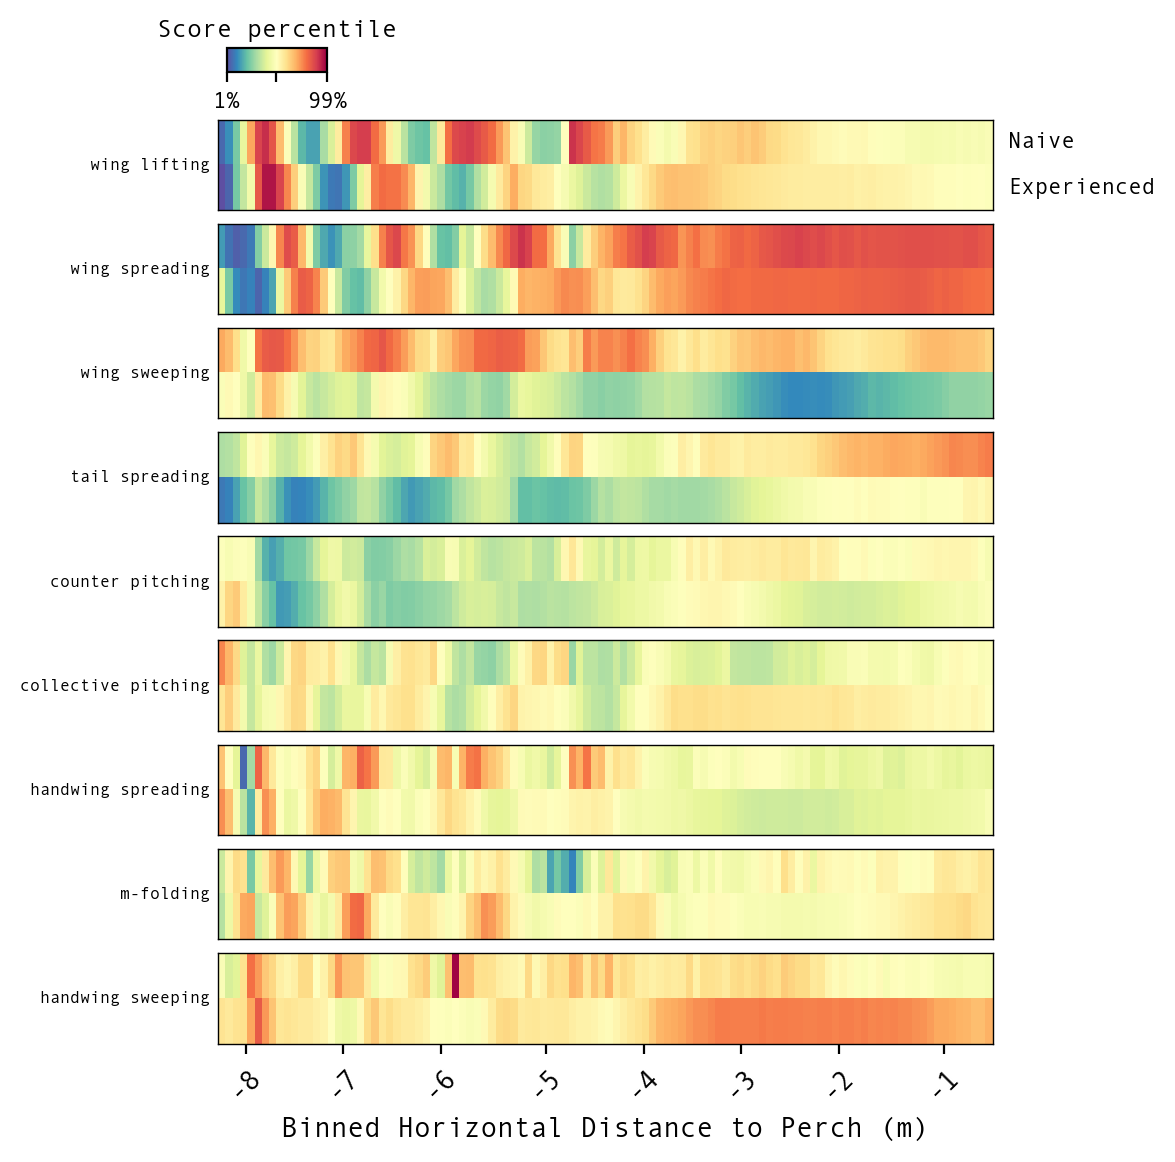

Saved: ../../figures/supplementary/S12_experience_Toothless.pdf


In [7]:
plt.close("all")
naive_hawks = ["Drogon", "Toothless"]

for hawk in naive_hawks:
    naive_df, exp_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": hawk},
        condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
    )
    print(f"--- {hawk}: naive vs experienced ---")
    ax = plot_difference_exp_scores_heatmap(
        exp_df, "Experienced", naive_df, "Naive", PC_cols, score_5, score_95
    )
    save_figure(ax, CONFIG["fig_dir"] / f"S12_experience_{hawk}.pdf")

- **Wing sweeping (PC03)** is the clearest signal. The naive juveniles held their wings near neutral or slightly forward-swept; the experienced adults adopt a consistently more backwards-swept posture.
- **Tail spreading (PC04)** decreases with experience in both hawks across all bins (−0.02 to −0.05).
- **Wing spreading (PC02)** For Toothless, his glide phase has a more gentle transition from flapping, and the glide is shorter overall. This could reflect mass changes with maturation or a smoother transition to gliding with experience. For Drogon, the wing spreading signature is more variable across the flight, but there is a clear increase in wing spread during the glide phase.
- **Counter pitching (PC05)** Drogon uses higher pitch angle of the wings as a juvenile, particularly on approach to the perch. 
- **Collective pitching (PC08)** Drogon adopts a strong positive pitch around halfway through the flights as an adult, associated with tail raising possibly related to the rapid pitch-up manoeuvre, a signal not present when he was a juvenile and not one used by Toothless at all. 
- **Handwing modes (PC06 & PC09)** Drogon uses higher handwing spreading when adult, the opposite for Toothless. Drogon also adopts a pronounced handwing sweep on take-off as an adult. Toothless also uses much more handwing sweep as an adult before landing whereas as a juvenile he uses more whole wing sweep at the shoulder over the whole flight. 
- **M-folding (PC07)** The adults show more m-folding, juvenile Toothless uses w-folding. 



## Heatmap Comparisons — Drogon vs Rhaegal (Naive)

Drogon and Rhaegal are brothers, both recorded as naive juveniles (Period 1). Comparing their morphing patterns reveals individual differences in flight style at a similar developmental stage.

Condition 1: Number of frames: 14550; Number of flights: 76
Condition 2: Number of frames: 28392; Number of flights: 114
--- Drogon vs Rhaegal (both naive) ---


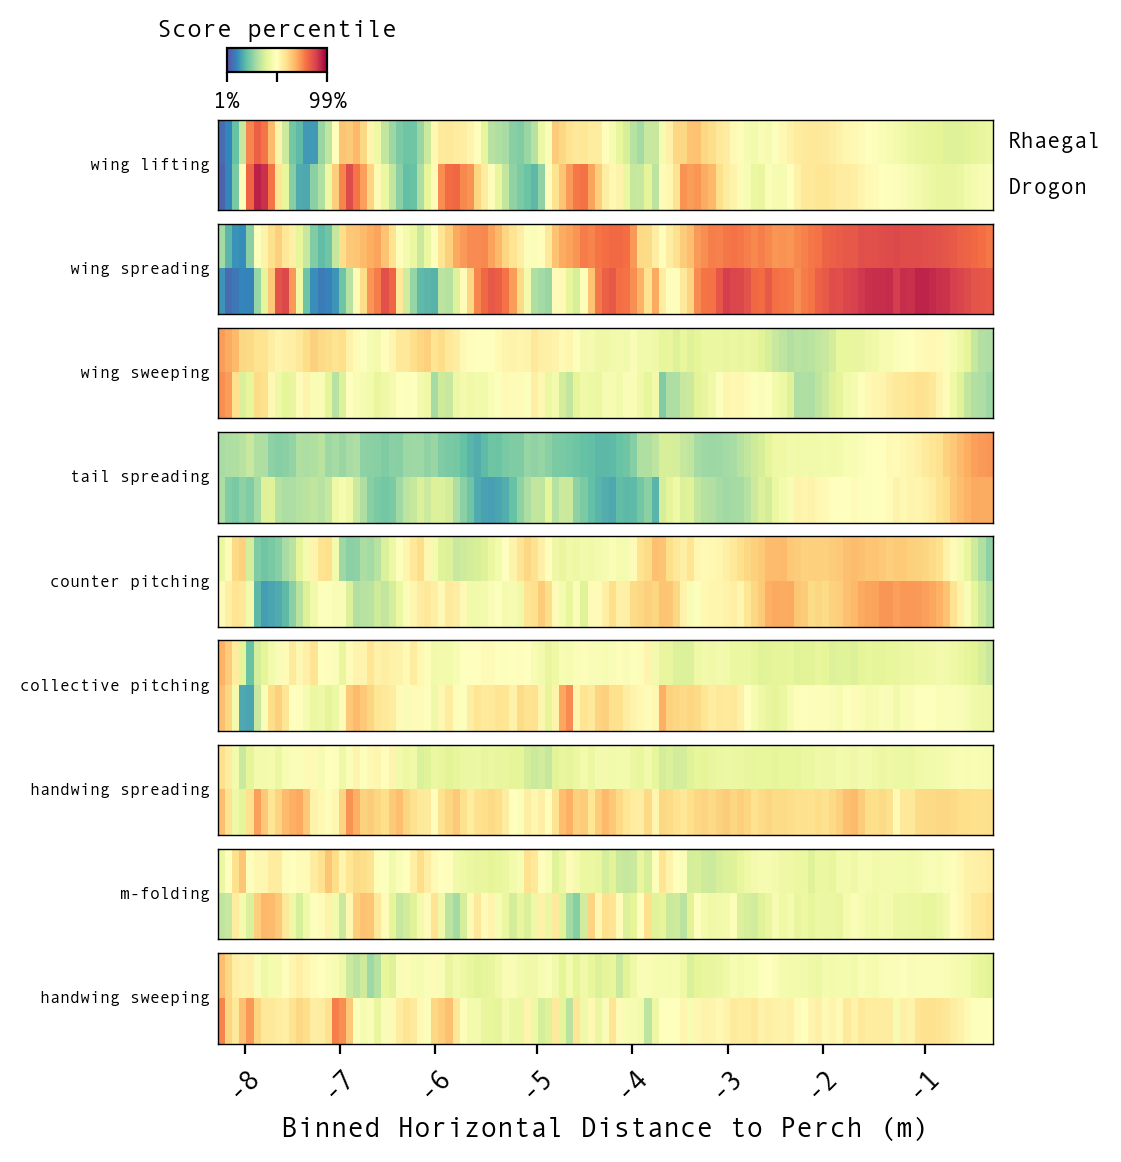

Saved: ../../figures/supplementary/S12_siblings_Drogon_Rhaegal.pdf


In [8]:
plt.close("all")

drogon_df, rhaegal_df, score_5, score_95 = prepare_heatmap_comparison(
    scores_df,
    reference_filters={"year": 2017},
    condition1={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": "Drogon"},
    condition2={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": "Rhaegal"},
)
print("--- Drogon vs Rhaegal (both naive) ---")
ax = plot_difference_exp_scores_heatmap(
    drogon_df, "Drogon", rhaegal_df, "Rhaegal", PC_cols, score_5, score_95
)
save_figure(ax, CONFIG["fig_dir"] / "S12_siblings_Drogon_Rhaegal.pdf")

Condition 1: Number of frames: 23456; Number of flights: 67
Condition 2: Number of frames: 15530; Number of flights: 66
--- Toothless vs Ruby (both experienced) ---


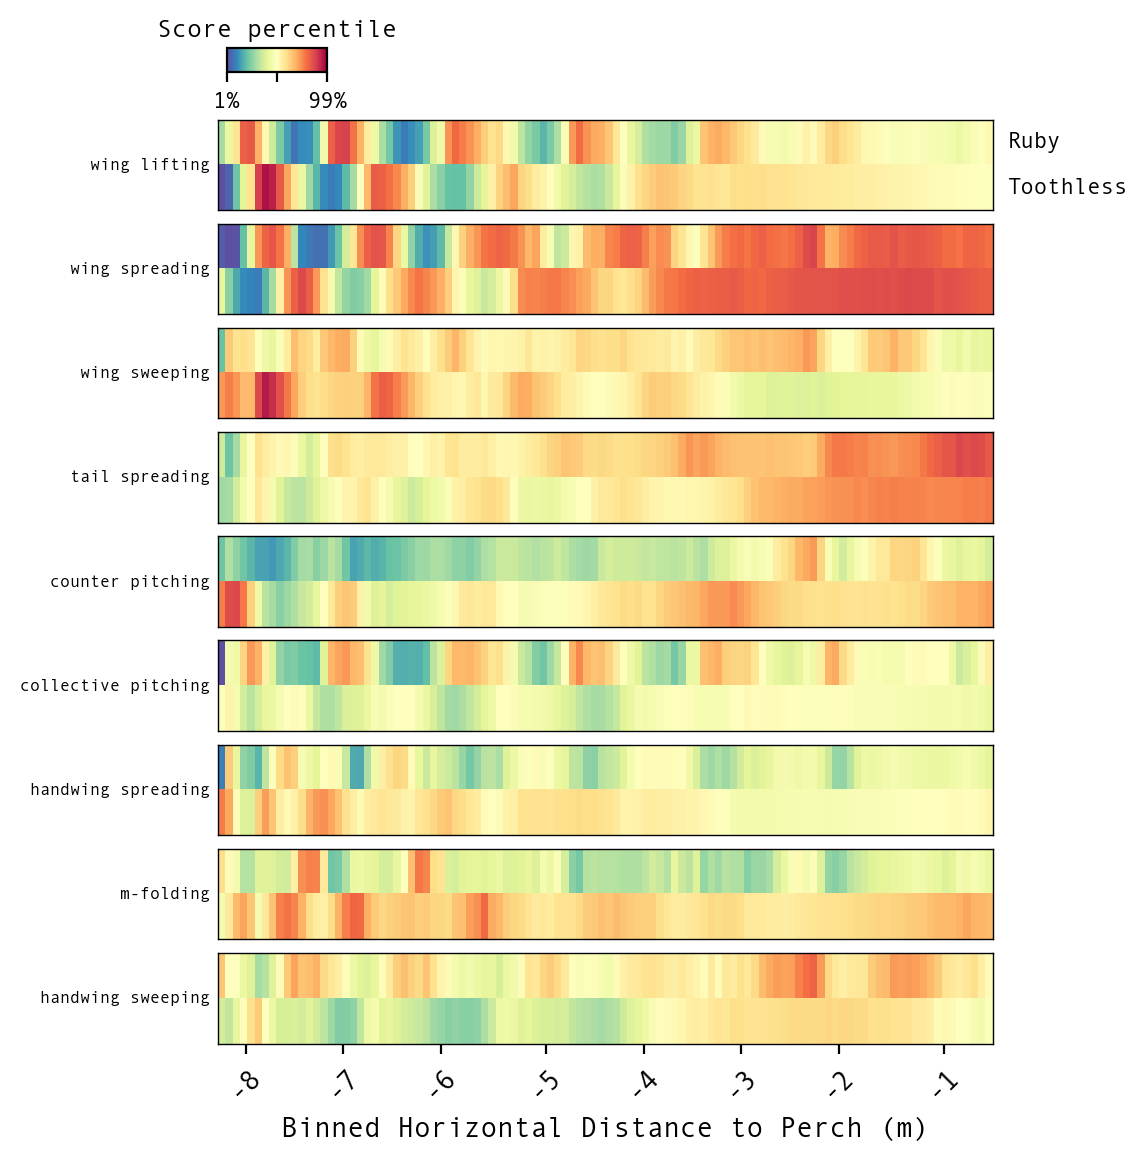

Saved: ../../figures/supplementary/S12_individuals_Toothless_Ruby.pdf


In [9]:
plt.close("all")

toothless_df, ruby_df, score_5, score_95 = prepare_heatmap_comparison(
    scores_df,
    reference_filters={"year": 2020},
    condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": "Toothless"},
    condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": "Ruby"},
)
print("--- Toothless vs Ruby (both experienced) ---")
ax = plot_difference_exp_scores_heatmap(
    toothless_df, "Toothless", ruby_df, "Ruby", PC_cols, score_5, score_95
)
save_figure(ax, CONFIG["fig_dir"] / "S12_individuals_Toothless_Ruby.pdf")

The individual comparisons reveal which morphing modes carry individual signatures — consistent differences that persist across the full approach rather than varying with distance:

**Siblings (Drogon vs Rhaegal, both naive Period 1):**

- **Wing lifting (PC01)** Drogon shows higher wing raising and overall higher flapping amplitude though their frequency is similar. 
- **Wing spreading (PC02)** The pattern of wing spreading during flapping shows a phase difference between the birds, and Drogon uses higher wing spread in gliding. They begin the glide at the same position. 
- **Wing sweeping (PC03)** During the wingbeats, Rhaegal uses more positive wing sweep while Drogon uses more negative. Drogon uses a more positive sweep close to the perch than Rhaegal. 
- **Tail Spreading (PC04)** The siblings show an extremely similar spreading pattern during landing, but Drogon uses alternating contraction and neutral spread during the wingbeats. 
- **Handwing modes (PC06 & PC09)** Drogon shows higher handwing spread and sweep throughout the flight compared to Rhaegal. 


**Experienced individuals (Toothless vs Ruby, both Period 2):**

- **Wing lifting (PC01)** Toothless uses fewer wingbeats and slower frequency, with a longer glide phase compared to Ruby. 
- **Wing sweeping (PC03)** Ruby uses more positive sweep throughout the flight, whileToothless uses much more pronounced positive sweep on take-off and slightly negative during landing. 
- **Tail spreading (PC04)** As Ruby has a shorter glide phase than Toothless, her wing spread is likely assisted by stronger tail span increase close to the destination perch. Overall she shows more tail spread throughout. 
- **Pitching (PC05 & PC09)** Ruby uses more variation in tail lifting, positive and negative, throughout the flight. She keeps wing pitching mostly negative with some short positive peaks close to the perch. Toothless is the opposite, his wing pitching is mostly positive with high peaks at take-off and the middle of the glide. His tail lifting is mostly negative with low variation, again opposite to Ruby's positive with high variation.  
- **Handwing modes (PC06 & PC09)** Toothless uses mostly negative handwing sweep and positive handwing spread, while Ruby uses more positive sweep and negative spread.
- **M-folding (PC07)** Toothless uses more m-folding while Ruby uses more w-folding.

## Summary

The heatmaps reveal that morphing patterns are highly individual-specific, with different hawks adopting distinct strategies to achieve similar flight outcomes.

**Obstacle flights** trigger both localised and global changes. The span-reduction at the obstacle (PC02) and accompanying tail spread (PC04) are consistent across hawks, but pitching strategies (PC05, PC08) differ markedly — Toothless uses collective pitching near the perch for turning while Ruby shows strong wing pitch during the delayed glide. Handwing adjustments (PC06, PC07, PC09) also vary individually. Obstacle flights are not simply "control flights plus a span-reduction" but show altered morphing throughout the entire approach.

**Added weight** reveals different compensation strategies. Charmander raises his wings higher under load and increases handwing spread, while Ruby abandons her glide phase entirely and flaps all the way to the perch with altered wingbeat timing. Both show altered tail spreading patterns, but Ruby's braking strategy shifts dramatically without a glide. These differences may reflect body size (Ruby is a larger female) or experience (Charmander was a juvenile).

**Experience** produces consistent changes in some modes but not others. Both Drogon and Toothless adopt more backwards wing sweep (PC03) and reduced tail spread (PC04) as experienced adults. However, their handwing strategies change in opposite directions — Drogon increases handwing spread while Toothless decreases it. Toothless develops a smoother glide transition while Drogon adopts new pitching patterns (PC08) not present as a juvenile. Adults generally show more m-folding (PC07).

**Individual signatures** are evident even between siblings at the same developmental stage. Drogon and Rhaegal show opposite wing sweep patterns during flapping and differ in handwing spread despite similar tail-spreading signatures during landing. Among experienced adults, Toothless and Ruby show opposite patterns across multiple modes: pitching, handwing spread and sweep, and m/w-folding. Ruby uses more positive sweep, tail spread, and w-folding; Toothless uses fewer wingbeats, a longer glide, and more m-folding.

| Comparison | Key finding |
|---|---|
| Obstacle | Span-reduction and tail spread consistent; pitching and handwing strategies individual-specific |
| Weight | Different compensation strategies: handwing adjustment vs. abandoning glide phase |
| Experience | Backwards sweep and reduced tail spread consistent; handwing and pitching changes individual |
| Siblings | Individual differences despite shared genetics and developmental stage |
| Experienced individuals | Opposite strategies across multiple modes achieving similar flight outcomes |

The dominant pattern across all comparisons is **individual variation**. While some morphing changes are consistent (obstacle span-reduction, experience-related sweep changes), hawks achieve similar flight goals through distinct combinations of morphing adjustments. The finer modes (pitching, handwing shape, m-folding) carry the strongest individual signatures, likely reflecting morphological differences or habitual motor strategies rather than task-driven responses.

> **Caveat:** These heatmaps visualise consistent within-individual behaviours. As variation is high both within and across individuals, they do not represent stereotyped generalisable patterns. Quantitative comparison across individuals would require methods that account for variable wingbeat frequencies and individual baselines.

---

## References

- KleinHeerenbrink, M., France, L. A., Brighton, C. H. & Taylor, G. K. (2022). Optimization of avian perching manoeuvres. *Nature*, 607, 91–96.